In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from oasis_data_loader import OASISDataLoader

data_loader = OASISDataLoader(batch_size=16, max_text_length=300)

# Get dataloaders
train_loader, test_loader, val_loader = data_loader.get_dataloaders()

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Columns in the dataframe:  Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'MRI-URL',
       'Generated_descriptions'],
      dtype='object')
Data in the dataloader: Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'MRI-URL',
       'Generated_descriptions', 'MMSE_bin', 'MMSE_bin_codes',
       'MMSE_transformed'],
      dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/torchio/data/image.py:248: UserWarning: Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.
  warnings.warn(message, stacklevel=1)


torch.Size([16])
torch.Size([16, 1, 256, 256, 128])
Columns in the dataframe:  Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'MRI-URL',
       'Generated_descriptions'],
      dtype='object')
Data in the dataloader: Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'MRI-URL',
       'Generated_descriptions', 'MMSE_bin', 'MMSE_bin_codes',
       'MMSE_transformed'],
      dtype='object')


## Get the training data

In [3]:
# Assuming you have a DataLoader named `data_loader`
train_images = []
train_mmse = []
train_input_ids = []
train_attention_masks = []
train_group = []

# Iterate through the DataLoader
for batch in train_loader:
    train_mmse.append(batch['mmse'])
    train_input_ids.append(batch['input_ids'])
    train_attention_masks.append(batch['attention_mask'])
    train_group.append(batch['group'])


# Concatenate all data into single tensors (if needed)

train_mmse = torch.cat(train_mmse, dim=0)
train_input_ids = torch.cat(train_input_ids, dim=0)
train_attention_masks = torch.cat(train_attention_masks, dim=0)

# Now you have all the data in tensors
print(f"All MMSE values shape: {train_mmse.shape}")
print(f"All input IDs shape: {train_input_ids.shape}")
print(f"All attention masks shape: {train_attention_masks.shape}")

train_mmse_mean = train_mmse.mean().item()
train_mmse_std = train_mmse.std().item()
train_mmse_min = train_mmse.min().item()
train_mmse_max = train_mmse.max().item()
train_mmse_median = train_mmse.median().item()

print(f"MMSE Mean: {train_mmse_mean}")
print(f"MMSE Standard Deviation: {train_mmse_std}")
print(f"MMSE Min: {train_mmse_min}")
print(f"MMSE Max: {train_mmse_max}")
print(f"MMSE Median: {train_mmse_median}")

train_group = torch.cat(train_group, dim=0)
# Count the number of each unique value in the train_group array
unique_groups, counts = torch.unique(train_group, return_counts=True)

# Print the counts for each unique group
for group, count in zip(unique_groups, counts):
    print(f"Group {group.item()}: {count.item()} samples")




/opt/anaconda3/lib/python3.12/site-packages/torchio/data/image.py:248: UserWarning: Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.
  warnings.warn(message, stacklevel=1)


All MMSE values shape: torch.Size([90])
All input IDs shape: torch.Size([90, 300])
All attention masks shape: torch.Size([90, 300])
MMSE Mean: 26.822221755981445
MMSE Standard Deviation: 4.71091890335083
MMSE Min: 4.0
MMSE Max: 30.0
MMSE Median: 29.0
Group 0: 43 samples
Group 1: 38 samples
Group 2: 9 samples


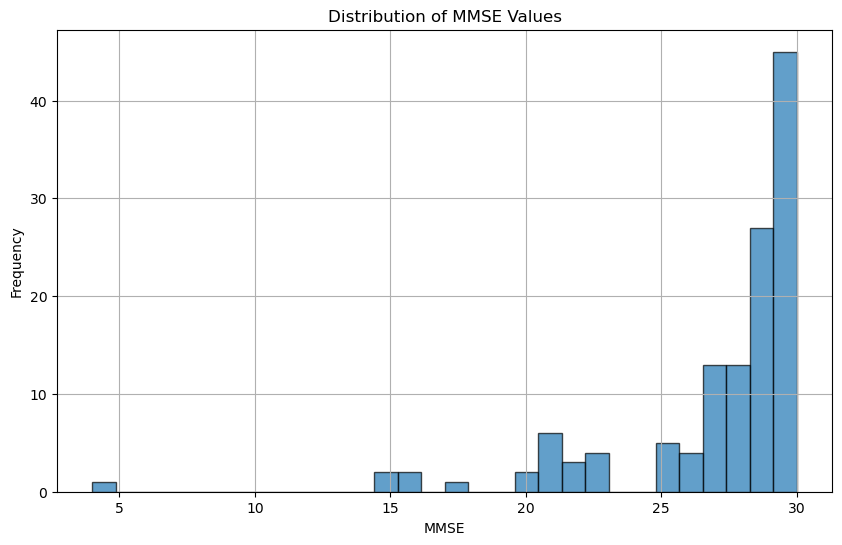

In [3]:
# Plot the distribution of the MMSE values
plt.figure(figsize=(10, 6))
plt.hist(train_mmse.numpy(), bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of MMSE Values')
plt.xlabel('MMSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


## Get the validation

In [4]:
# Assuming you have a DataLoader named `data_loader`
val_images = []
val_mmse = []
val_input_ids = []
val_attention_masks = []
val_group = []

# Iterate through the DataLoader
for batch in val_loader:
    val_mmse.append(batch['mmse'])
    val_input_ids.append(batch['input_ids'])
    val_attention_masks.append(batch['attention_mask'])
    val_group.append(batch['group'])

# Concatenate all data into single tensors (if needed)

val_mmse = torch.cat(val_mmse, dim=0)
val_input_ids = torch.cat(val_input_ids, dim=0)
val_attention_masks = torch.cat(val_attention_masks, dim=0)

# Now you have all the data in tensors
print(f"All MMSE values shape: {val_mmse.shape}")
print(f"All input IDs shape: {val_input_ids.shape}")
print(f"All attention masks shape: {val_attention_masks.shape}")
# Print descriptive statistics for the MMSE values
mmse_mean = val_mmse.mean().item()
mmse_std = val_mmse.std().item()
mmse_min = val_mmse.min().item()
mmse_max = val_mmse.max().item()
mmse_median = val_mmse.median().item()

print(f"MMSE Mean: {mmse_mean}")
print(f"MMSE Standard Deviation: {mmse_std}")
print(f"MMSE Min: {mmse_min}")
print(f"MMSE Max: {mmse_max}")
print(f"MMSE Median: {mmse_median}")

val_group = torch.cat(val_group, dim=0)
# Count the number of each unique value in the val_group array
unique_groups, counts = torch.unique(val_group, return_counts=True)

# Print the counts for each unique group
for group, count in zip(unique_groups, counts):
    print(f"Group {group.item()}: {count.item()} samples")


All MMSE values shape: torch.Size([30])
All input IDs shape: torch.Size([30, 300])
All attention masks shape: torch.Size([30, 300])
MMSE Mean: 26.899999618530273
MMSE Standard Deviation: 3.526745080947876
MMSE Min: 17.0
MMSE Max: 30.0
MMSE Median: 28.0
Group 0: 13 samples
Group 1: 12 samples
Group 2: 5 samples


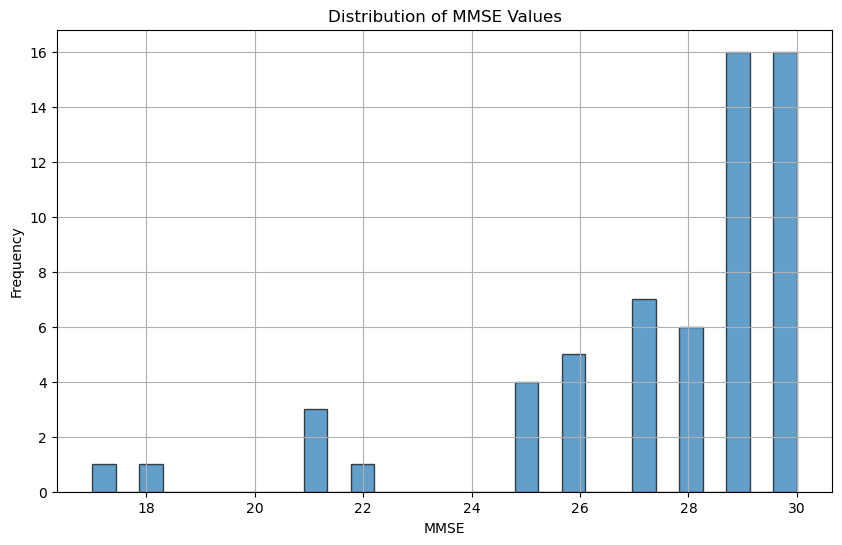

In [5]:
# Plot the distribution of the MMSE values
plt.figure(figsize=(10, 6))
plt.hist(val_mmse.numpy(), bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of MMSE Values')
plt.xlabel('MMSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Get the testing data

In [6]:
# Assuming you have a DataLoader named `data_loader`
test_images = []
test_mmse = []
test_input_ids = []
test_attention_masks = []

# Iterate through the DataLoader
for batch in test_loader:
    test_mmse.append(batch['mmse'])
    test_input_ids.append(batch['input_ids'])
    test_attention_masks.append(batch['attention_mask'])

# Concatenate all data into single tensors (if needed)

test_mmse = torch.cat(test_mmse, dim=0)
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

# Now you have all the data in tensors
print(f"All MMSE values shape: {test_mmse.shape}")
print(f"All input IDs shape: {test_input_ids.shape}")
print(f"All attention masks shape: {test_attention_masks.shape}")

All MMSE values shape: torch.Size([64])
All input IDs shape: torch.Size([64, 300])
All attention masks shape: torch.Size([64, 300])


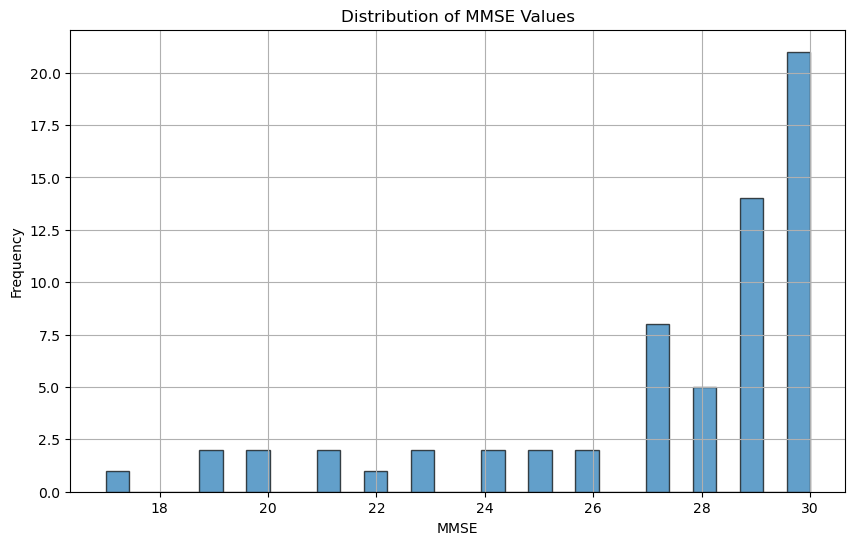

In [7]:
# Plot the distribution of the MMSE values
plt.figure(figsize=(10, 6))
plt.hist(test_mmse.numpy(), bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of MMSE Values')
plt.xlabel('MMSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [8]:
from math import factorial

k = 195  # Total countries
n = 30   # Students

prob_all_different = factorial(k) / (factorial(k - n) * (k ** n))
print(prob_all_different)

0.09511898588539562
